# Task 1 - Data preparation

## 1.1  Load uqa/UQA, keep rows that have an answer

In [1]:
from datasets import load_dataset

ds = load_dataset("uqa/UQA")
ds

README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

data/train-00000-of-00001-bac007e8ca7192(…):   0%|          | 0.00/30.2M [00:00<?, ?B/s]

data/validation-00000-of-00001-cf8a6960d(…):   0%|          | 0.00/2.92M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/124745 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16824 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})

In [2]:
r = ds["train"][0]
r

{'id': '56be85543aeaaa14008c9063',
 'title': 'بیونسے',
 'context': "Beyoncé Giselle Knowles-Carter (/biː'j ⁇ nseɪ/ bee-YON-say) (پیدائش 4 ستمبر 1981) ایک امریکی گلوکارہ ، گانا لکھنے والی ، ریکارڈ پروڈیوسر اور اداکارہ ہیں۔ ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔ اس کے والد ، میتھیو نولز کے زیر انتظام ، یہ گروپ دنیا کے سب سے زیادہ فروخت ہونے والے گرل گروپس میں سے ایک بن گیا۔ ان کے وقفے نے بیونس کی پہلی البم ، خطرناک طور پر محبت میں (2003) کی رہائی دیکھی ، جس نے اسے دنیا بھر میں ایک سولو آرٹسٹ کے طور پر قائم کیا ، پانچ گریمی ایوارڈز حاصل کیے اور بل بورڈ ہاٹ 100 میں نمبر ون سنگلز میں محبت اور بچے پاگل لڑکے۔",
 'question': 'بیونس نے کب مقبولیت حاصل کرنا شروع کی؟',
 'is_impossible': False,
 'answer': '1990 کی دہائی کے آخر میں',
 'answer_start': 273}

In [3]:
# check what an unanswerable row looks like
for r in ds["train"]:
    if r["is_impossible"]:
        print("answer:", repr(r["answer"]))
        print("answer_start:", r["answer_start"])
        break

answer: ''
answer_start: -1


In [4]:
# Appendix A.2 loads the data 
train_data = []
for r in ds["train"]:
    if r["is_impossible"]:
        continue
    if r["answer"] == "":
        continue
    train_data.append(r)

valid_data = []
for r in ds["validation"]:
    if r["is_impossible"]:
        continue
    if r["answer"] == "":
        continue
    valid_data.append(r)

print("train rows kept:", len(train_data))
print("valid rows kept:", len(valid_data))

train rows kept: 83018
valid rows kept: 11169


## 1.2  Find the sentence that contains the answer (character offsets)

In [5]:
#  sir code (Appendix A.3)
SENT_DELIMS = "\u06D4\u061F!"  

def split_sentences(text):
    start = 0
    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1
    if start < len(text):
        yield start, len(text), text[start:]

In [6]:
# check example
r = train_data[0]
a_start = r["answer_start"]

for start, end, sent in split_sentences(r["context"]):
    if start <= a_start < end:
        print("answer:")
        print(r["answer"])
        print("sentence:")
        print(sent)
        break

answer:
1990 کی دہائی کے آخر میں
sentence:
 ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔


## 1.3 - 1.4  Wrap the answer in `<ans>`, drop long pairs

In [7]:

# make_pair is from Appendix A.3, first 3 lines changed for the flat fields

ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"

def make_pair(row, max_src=60, max_tgt=25):
    a_start = row["answer_start"]
    a_text = row["answer"]
    context = row["context"]

    for start, end, sent in split_sentences(context):
        if start <= a_start < end:
            pos = a_start - start
            if sent[pos:pos + len(a_text)] != a_text:
                return None

            before = sent[:pos]
            after = sent[pos + len(a_text):]
            src = before + " " + ANS_OPEN + " " + a_text + " " + ANS_CLOSE + " " + after
            src = " ".join(src.split())
            tgt = " ".join(row["question"].split())

            # 1.4 - skip if source or target is too long
            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None
            return src, tgt
    return None

In [8]:
p = make_pair(train_data[0])
print("source:")
print(p[0])
print("target:")
print(p[1])

source:
ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
target:
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟


## 1.5  Write train.tsv / valid.tsv, counts and length histograms

In [9]:
# sir code (Appendix A.3)
import csv

def build_split(split, out_path):
    pairs = [p for p in map(make_pair, split) if p is not None]
    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(f, delimiter="\t", quoting=csv.QUOTE_NONE, escapechar="\\")
        w.writerows(pairs)
    print(out_path, len(pairs), "pairs")
    return pairs

train_pairs = build_split(train_data, "train.tsv")
valid_pairs = build_split(valid_data, "valid.tsv")

train.tsv 75067 pairs
valid.tsv 10018 pairs


## Histograms

train pairs:
75067
valid pairs:
10018
average source length:
32.58679579575579
average target length:
11.919991474282973


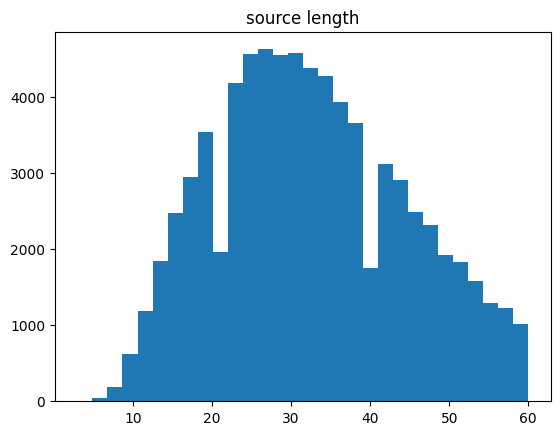

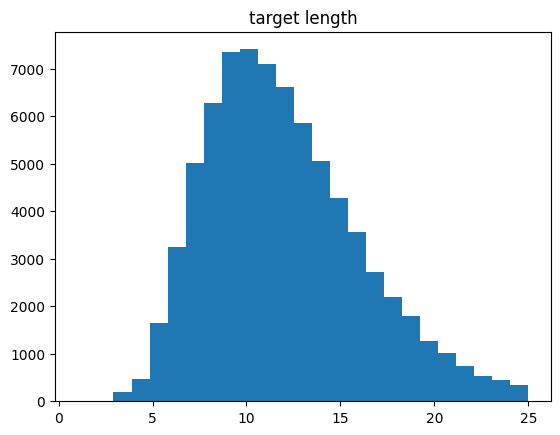

In [10]:
import matplotlib.pyplot as plt

src_len = []
tgt_len = []
for s, t in train_pairs:
    src_len.append(len(s.split()))
    tgt_len.append(len(t.split()))

print("train pairs:")
print(len(train_pairs))
print("valid pairs:")
print(len(valid_pairs))
print("average source length:")
print(sum(src_len) / len(src_len))
print("average target length:")
print(sum(tgt_len) / len(tgt_len))

plt.hist(src_len, bins=30)
plt.title("source length")
plt.show()

plt.hist(tgt_len, bins=25)
plt.title("target length")
plt.show()

# Task 2 - Tokenizer

## 2.1  Train SentencePiece (vocab 8k) on the training sources and targets

In [11]:
# sir code (Appendix A.4)
with open("sp_corpus.txt", "w", encoding="utf-8") as f:
    for src, tgt in train_pairs:
        f.write(src + "\n")
        f.write(tgt + "\n")

In [12]:
# sir code (Appendix A.4)
import sentencepiece as spm

spm.SentencePieceTrainer.train(
    input="sp_corpus.txt",
    model_prefix="ur_sp",
    vocab_size=8000,
    model_type="unigram",
    character_coverage=1.0,
    user_defined_symbols=[ANS_OPEN, ANS_CLOSE],
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: sp_corpus.txt
  input_format: 
  model_prefix: ur_sp
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <ans>
  user_defined_symbols: </ans>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_

## 2.2  `<ans>` `</ans>` as user-defined symbols; `<pad> <unk> <s> </s>` reserved



In [13]:
sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
PAD, UNK, BOS, EOS = 0, 1, 2, 3

print("vocab size:")
print(sp.get_piece_size())

print("first 6 pieces:")
for i in range(6):
    print(i, sp.id_to_piece(i))

vocab size:
8000
first 6 pieces:
0 <pad>
1 <unk>
2 <s>
3 </s>
4 <ans>
5 </ans>


## 2.3  Five tokenised examples

In [14]:
for i in range(5):
    src, tgt = train_pairs[i]
    pieces = sp.encode(src, out_type=str)
    print("example", i + 1)
    print(src)
    print(pieces)
    print()

example 1
ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
['▁ہی', 'وسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پر', 'ورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁', 'بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابل', 'وں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گرل', '▁گروپ', '▁ڈسٹ', 'نی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']

example 2
ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں آر اینڈ بی گرل گروپ ڈسٹنی چائلڈ کی لیڈ گلوکارہ کی حیثیت سے شہرت حاصل کی۔
['▁ہی', 'وسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁اور', '▁پر', 'ورش', '▁پائی', '▁

 How Urdu gets split:
 
1:words like کے، میں، اور never break, they're common so they got their own piece
2:some breaks make sense - like گلوکار splits into گلوکار + ہ, sنگل splits into سنگل + ز, so it's basically catching the suffix
3:some breaks don't make sense at all, just random - ہیوسٹن became ہی + وسٹن, پاگل became پا + گل, no real reason
4:same word doesn't always split the same way either, ٹیکساس stayed as one piece but ہیوسٹن got split, probably just came up more in training
5:ans and /ans tags never split since we told it not to

# Task 3 - Model

One RNN encoder-decoder with attention, built from `nn.Embedding`, `nn.LSTM`, `nn.Linear`. 

## Data pipeline

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [16]:
MAX_SRC = 60
MAX_TGT = 25

class QGData(Dataset):
    def __init__(self, path):
        self.pairs = []
        for line in open(path, encoding="utf-8"):
            line = line.strip()
            if "\t" not in line:
                continue
            src, tgt = line.split("\t")
            src_ids = sp.encode(src)[:MAX_SRC]
            tgt_ids = sp.encode(tgt)[:MAX_TGT]
            self.pairs.append((src_ids, [BOS] + tgt_ids + [EOS]))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        return self.pairs[i]

In [17]:
def collate(batch):
    batch = sorted(batch, key=lambda x: len(x[0]), reverse=True)
    src_list = [x[0] for x in batch]
    tgt_list = [x[1] for x in batch]

    src_lens = torch.tensor([len(s) for s in src_list])
    src_max = max(src_lens).item()
    tgt_max = max(len(t) for t in tgt_list)

    src_pad = torch.zeros(len(batch), src_max, dtype=torch.long)
    tgt_pad = torch.zeros(len(batch), tgt_max, dtype=torch.long)
    for i in range(len(batch)):
        s = src_list[i]
        t = tgt_list[i]
        src_pad[i, :len(s)] = torch.tensor(s)
        tgt_pad[i, :len(t)] = torch.tensor(t)

    return src_pad, src_lens, tgt_pad

In [18]:
train_set = QGData("train.tsv")
valid_set = QGData("valid.tsv")

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, collate_fn=collate)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False, collate_fn=collate)

print("train pairs:")
print(len(train_set))
print("valid pairs:")
print(len(valid_set))

train pairs:
75067
valid pairs:
10018


## Encoder : 2-layer bidirectional LSTM

In [19]:
class Encoder(nn.Module):
    def __init__(self, vocab, emb=256, hid=512, n_layers=2, drop=0.3):
        super().__init__()
        self.hid = hid
        self.n_layers = n_layers
        self.embed = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.rnn = nn.LSTM(emb, hid, n_layers, batch_first=True,
                            bidirectional=True, dropout=drop)
        self.fc_h = nn.Linear(hid * 2, hid)
        self.fc_c = nn.Linear(hid * 2, hid)
        self.drop = nn.Dropout(drop)

    def forward(self, x, lens):
        e = self.drop(self.embed(x))
        packed = nn.utils.rnn.pack_padded_sequence(e, lens.cpu(), batch_first=True)
        out, (h, c) = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)

        h = h.view(self.n_layers, 2, h.size(1), self.hid)
        h = torch.cat((h[:, 0], h[:, 1]), dim=2)
        h = torch.tanh(self.fc_h(h))

        c = c.view(self.n_layers, 2, c.size(1), self.hid)
        c = torch.cat((c[:, 0], c[:, 1]), dim=2)
        c = torch.tanh(self.fc_c(c))

        return out, (h, c)

## Attention  Bahdanau

In [20]:
class Attention(nn.Module):
    def __init__(self, enc_dim=1024, hid=512):
        super().__init__()
        self.w1 = nn.Linear(enc_dim, hid, bias=False)
        self.w2 = nn.Linear(hid, hid, bias=False)
        self.v = nn.Linear(hid, 1, bias=False)

    def forward(self, dec_h, enc_out, mask):
        score = self.v(torch.tanh(self.w2(dec_h).unsqueeze(1) + self.w1(enc_out)))
        score = score.squeeze(2)
        score = score.masked_fill(mask, float("-inf"))
        a = torch.softmax(score, dim=1)
        ctx = torch.bmm(a.unsqueeze(1), enc_out).squeeze(1)
        return ctx, a

## Decoder - one timestep

In [21]:
class Decoder(nn.Module):
    def __init__(self, vocab, emb=256, hid=512, n_layers=2, drop=0.3, enc_dim=1024):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.attn = Attention(enc_dim, hid)
        self.rnn = nn.LSTM(emb + enc_dim, hid, n_layers, batch_first=True, dropout=drop)
        self.fc_out = nn.Linear(hid + enc_dim, vocab)
        self.drop = nn.Dropout(drop)

    def forward(self, tok, hid, enc_out, mask):
        h, c = hid
        e = self.drop(self.embed(tok)).unsqueeze(1)
        ctx, a = self.attn(h[-1], enc_out, mask)
        rnn_in = torch.cat((e, ctx.unsqueeze(1)), dim=2)
        out, (h, c) = self.rnn(rnn_in, (h, c))
        out = out.squeeze(1)
        pred = self.fc_out(torch.cat((out, ctx), dim=1))
        return pred, (h, c), a

## Seq2Seq wrapper - teacher forcing

In [22]:
class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc
        self.dec = dec

    def forward(self, x, x_len, y, tf=0.5):
        enc_out, hid = self.enc(x, x_len)
        mask = (x == PAD)

        bs = y.size(0)
        steps = y.size(1)
        vocab = self.dec.fc_out.out_features
        out = torch.zeros(bs, steps - 1, vocab).to(x.device)

        tok = y[:, 0]
        for t in range(1, steps):
            pred, hid, _ = self.dec(tok, hid, enc_out, mask)
            out[:, t - 1] = pred
            tok = y[:, t] if torch.rand(1).item() < tf else pred.argmax(1)

        return out

In [23]:
vocab = sp.get_piece_size()
enc = Encoder(vocab)
dec = Decoder(vocab)
model = Seq2Seq(enc, dec).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable parameters:")
print(n_params)

trainable parameters:
33457472


## Training : cross entropy ignoring padding, Adam

In [24]:
def run_epoch(loader, train=True):
    model.train(train)
    loss_sum = 0
    tok_sum = 0

    for x, x_len, y in loader:
        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):
            tf = 0.5 if train else 1.0
            out = model(x, x_len, y, tf=tf)
            gold = y[:, 1:].reshape(-1)
            loss = F.cross_entropy(out.reshape(-1, out.size(-1)), gold,
                                    ignore_index=PAD, reduction="sum")
            n_tok = (gold != PAD).sum().item()

        if train:
            opt.zero_grad()
            (loss / n_tok).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        loss_sum += loss.item()
        tok_sum += n_tok

    return loss_sum / tok_sum

In [26]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 10
best = float("inf")
history = []

for ep in range(1, epochs + 1):
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(valid_loader, train=False)
    history.append((tr_loss, va_loss))

    print("epoch",ep)
    print("train loss",tr_loss)
    print("valid loss",va_loss)

    if va_loss < best:
        best = va_loss
        torch.save(model.state_dict(), "best.pt")

epoch 1
train loss 4.237109419396085
valid loss 3.9255578305737497
epoch 2
train loss 3.9114145605972204
valid loss 3.81222914078076
epoch 3
train loss 3.6689171295313274
valid loss 3.7902728951471794
epoch 4
train loss 3.47679804503828
valid loss 3.795333765831838
epoch 5
train loss 3.3162584521356844
valid loss 3.784623883581102
epoch 6
train loss 3.2059875747394058
valid loss 3.8273325398548637
epoch 7
train loss 3.101318846063525
valid loss 3.8667414636262043
epoch 8
train loss 3.0122372285231873
valid loss 3.8772945877281297
epoch 9
train loss 2.9306307217927117
valid loss 3.903220508413555
epoch 10
train loss 2.856739954791161
valid loss 3.928175152141777


## Loss per epoch

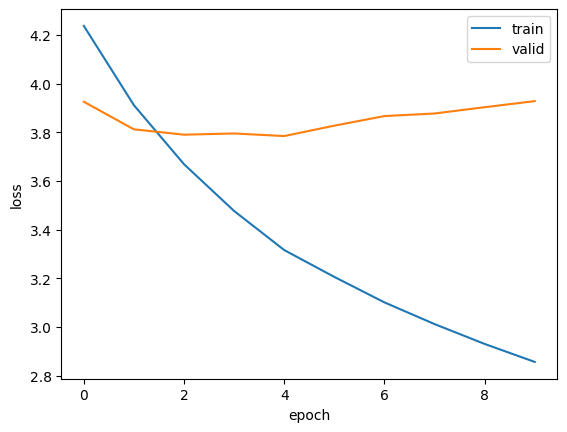

In [27]:
import matplotlib.pyplot as plt

train_hist = [h[0] for h in history]
val_hist = [h[1] for h in history]

plt.plot(train_hist, label="train")
plt.plot(val_hist, label="valid")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

## Decoding - greedy

In [29]:
def greedy_decode(text, max_len=30):
    model.eval()
    ids = sp.encode(text)[:MAX_SRC]
    x = torch.tensor([ids]).to(device)
    x_len = torch.tensor([len(ids)])

    with torch.no_grad():
        enc_out, hid = model.enc(x, x_len)
        mask = (x == PAD)
        tok = torch.tensor([BOS]).to(device)
        out_ids = []

        for _ in range(max_len):
            pred, hid, _ = model.dec(tok, hid, enc_out, mask)
            tok = pred.argmax(1)
            if tok.item() == EOS:
                break
            out_ids.append(tok.item())

    return sp.decode(out_ids)

## Decoding - beam search

In [30]:
def beam_decode(text, k=4, max_len=30):
    model.eval()
    ids = sp.encode(text)[:MAX_SRC]
    x = torch.tensor([ids]).to(device)
    x_len = torch.tensor([len(ids)])

    with torch.no_grad():
        enc_out, hid = model.enc(x, x_len)
        mask = (x == PAD)

        beams = [([BOS], 0.0, hid)]
        done = []

        for _ in range(max_len):
            pool = []
            for seq, score, h in beams:
                tok = torch.tensor([seq[-1]]).to(device)
                pred, h2, _ = model.dec(tok, h, enc_out, mask)
                logp = torch.log_softmax(pred, dim=1).squeeze(0)
                top_p, top_i = logp.topk(k)

                for p, i in zip(top_p.tolist(), top_i.tolist()):
                    new_seq = seq + [i]
                    new_score = score + p
                    if i == EOS:
                        done.append((new_seq, new_score))
                    else:
                        pool.append((new_seq, new_score, h2))

            pool.sort(key=lambda b: b[1] / len(b[0]), reverse=True)
            beams = pool[:k]
            if not beams:
                break

        done += [(s, sc) for s, sc, _ in beams]
        done.sort(key=lambda b: b[1] / len(b[0]), reverse=True)
        best = done[0][0]

    return sp.decode([t for t in best if t not in (BOS, EOS)])

In [31]:
sample = train_pairs[0][0]
print("greedy:")
print(greedy_decode(sample))
print("beam:")
print(beam_decode(sample))

greedy:
بیونس نے کب مقبولیت حاصل حاصل کی؟
beam:
بیونس نے کب مقبولیت حاصل حاصل کی؟


# Task 4 - Evaluation

Evaluate the best checkpoint on UQA validation and on Wiki-UQA, greedy and beam. Save `results/samples.tsv`.

In [32]:
model.load_state_dict(torch.load("best.pt"))
model.eval()
print("checkpoint loaded")

checkpoint loaded


In [33]:
!pip install sacrebleu rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 7.4 MB/s eta 0:00:00


Scoring function - based on Appendix A.5. The rouge_score library's default tokenizer only matches a-z/A-Z/0-9, so it treats every Urdu sentence as empty and ROUGE-L comes out 0 for every row. `SpaceTokenizer` fixes that by splitting on whitespace instead.

In [34]:
import sacrebleu
from rouge_score import rouge_scorer

class SpaceTokenizer:
    def tokenize(self, text):
        return text.split()

def score(hyps, refs):
    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False, tokenizer=SpaceTokenizer())
    rl = sum(scorer.score(r, h)["rougeL"].fmeasure for h, r in zip(hyps, refs)) / len(refs)
    unk_rate = sum(h.count("\u2047") for h in hyps) / max(1, sum(len(h.split()) for h in hyps))
    return {"BLEU-4": bleu, "ROUGE-L": rl, "unk_rate": unk_rate}

Wiki-UQA through the same pipeline as Task 1 (`make_pair` reused).

In [35]:
wiki = load_dataset("uqa/Wiki-UQA")
wiki_split = wiki["train"]

wiki_pairs = []
for row in wiki_split:
    p = make_pair(row)
    if p is not None:
        wiki_pairs.append(p)

print("wiki pairs:")
print(len(wiki_pairs))

README.md:   0%|          | 0.00/489 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/76.0k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/210 [00:00<?, ? examples/s]

wiki pairs:
177


In [36]:
def decode_all(pairs, limit=None):
    rows = pairs if limit is None else pairs[:limit]
    src_list = []
    ref_list = []
    greedy_list = []
    beam_list = []
    for src, tgt in rows:
        src_list.append(src)
        ref_list.append(tgt)
        greedy_list.append(greedy_decode(src))
        beam_list.append(beam_decode(src))
    return src_list, ref_list, greedy_list, beam_list

In [37]:
uqa_src, uqa_ref, uqa_greedy, uqa_beam = decode_all(valid_pairs, limit=200)

print("UQA valid - greedy")
print(score(uqa_greedy, uqa_ref))
print("UQA valid - beam")
print(score(uqa_beam, uqa_ref))

UQA valid - greedy
{'BLEU-4': 2.17238828797224, 'ROUGE-L': 0.20344660179696103, 'unk_rate': 0.0018788163457022077}
UQA valid - beam
{'BLEU-4': 4.827445025065035, 'ROUGE-L': 0.2098144014024881, 'unk_rate': 0.005977011494252874}


In [38]:
wiki_src, wiki_ref, wiki_greedy, wiki_beam = decode_all(wiki_pairs)

print("Wiki-UQA - greedy")
print(score(wiki_greedy, wiki_ref))
print("Wiki-UQA - beam")
print(score(wiki_beam, wiki_ref))

Wiki-UQA - greedy
{'BLEU-4': 3.593321719889097, 'ROUGE-L': 0.2065838103103532, 'unk_rate': 0.010290556900726392}
Wiki-UQA - beam
{'BLEU-4': 4.358731014763714, 'ROUGE-L': 0.21082714641699216, 'unk_rate': 0.008680555555555556}


Perplexity of the best checkpoint on the full validation set.

In [39]:
val_loss = run_epoch(valid_loader, train=False)
print("valid loss")
print(val_loss)
print("perplexity")
print(2.718281828 ** val_loss)

valid loss
3.784623883581102
perplexity
44.01911110623291


`results/samples.tsv` - at least 50 validation examples.

In [40]:
import os
import csv

os.makedirs("results", exist_ok=True)

with open("results/samples.tsv", "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f, delimiter="\t")
    w.writerow(["source", "reference", "greedy", "beam"])
    for i in range(len(uqa_src)):
        w.writerow([uqa_src[i], uqa_ref[i], uqa_greedy[i], uqa_beam[i]])

print("rows written")
print(len(uqa_src))

rows written
200


In [41]:
def greedy_with_attn(text, max_len=30):
    model.eval()
    ids = sp.encode(text)[:MAX_SRC]
    x = torch.tensor([ids]).to(device)
    x_len = torch.tensor([len(ids)])

    with torch.no_grad():
        enc_out, hid = model.enc(x, x_len)
        mask = (x == PAD)
        tok = torch.tensor([BOS]).to(device)
        out_ids = []
        attn_rows = []
        for _ in range(max_len):
            pred, hid, a = model.dec(tok, hid, enc_out, mask)
            tok = pred.argmax(1)
            if tok.item() == EOS:
                break
            out_ids.append(tok.item())
            attn_rows.append(a.squeeze(0).cpu())

    return out_ids, torch.stack(attn_rows)


/tmp/ipykernel_58/199337339.py:12: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/199337339.py:12: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_58/199337339.py:12: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/199337339.py:12: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/199337339.py:13: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("results/attention.png", dpi=120)
/tmp/ipykernel_58/199337339.py:13: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("results/attention.png", dpi=120)
/tmp/ipykernel_58/199337339.py:13: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.

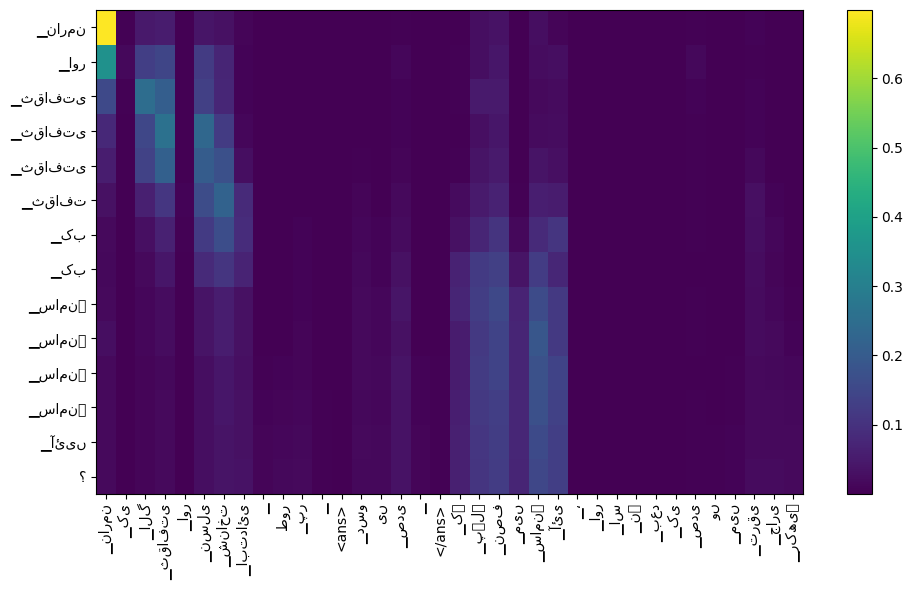

In [42]:
sample = valid_pairs[5][0]
out_ids, attn = greedy_with_attn(sample)

src_pieces = sp.encode(sample, out_type=str)
gen_pieces = [sp.id_to_piece(i) for i in out_ids]

plt.figure(figsize=(10, 6))
plt.imshow(attn[:, :len(src_pieces)].numpy(), aspect="auto")
plt.xticks(range(len(src_pieces)), src_pieces, rotation=90)
plt.yticks(range(len(gen_pieces)), gen_pieces)
plt.colorbar()
plt.tight_layout()
plt.savefig("results/attention.png", dpi=120)
plt.show()


In [43]:

import random

random.seed(42)
sample_rows = random.sample(list(zip(uqa_src, uqa_ref, uqa_beam)), 50)

with open("results/human_eval.csv", "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["source", "reference", "generated", "fluency", "relevance", "answerability"])
    for src, ref, gen in sample_rows:
        w.writerow([src, ref, gen, "", "", ""])

print("saved")


saved


# Task 5 - Front end

Gradio page

In [44]:
!pip install gradio

In [45]:
%%writefile app.py
import torch
import gradio as gr
import sentencepiece as spm
import torch.nn as nn

PAD, UNK, BOS, EOS = 0, 1, 2, 3
MAX_SRC = 60
device = "cpu"

class Encoder(nn.Module):
    def __init__(self, vocab, emb=256, hid=512, n_layers=2, drop=0.3):
        super().__init__()
        self.hid = hid
        self.n_layers = n_layers
        self.embed = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.rnn = nn.LSTM(emb, hid, n_layers, batch_first=True, bidirectional=True, dropout=drop)
        self.fc_h = nn.Linear(hid * 2, hid)
        self.fc_c = nn.Linear(hid * 2, hid)
        self.drop = nn.Dropout(drop)

    def forward(self, x, lens):
        e = self.drop(self.embed(x))
        packed = nn.utils.rnn.pack_padded_sequence(e, lens.cpu(), batch_first=True)
        out, (h, c) = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        h = h.view(self.n_layers, 2, h.size(1), self.hid)
        h = torch.tanh(self.fc_h(torch.cat((h[:, 0], h[:, 1]), dim=2)))
        c = c.view(self.n_layers, 2, c.size(1), self.hid)
        c = torch.tanh(self.fc_c(torch.cat((c[:, 0], c[:, 1]), dim=2)))
        return out, (h, c)

class Attention(nn.Module):
    def __init__(self, enc_dim=1024, hid=512):
        super().__init__()
        self.w1 = nn.Linear(enc_dim, hid, bias=False)
        self.w2 = nn.Linear(hid, hid, bias=False)
        self.v = nn.Linear(hid, 1, bias=False)

    def forward(self, dec_h, enc_out, mask):
        score = self.v(torch.tanh(self.w2(dec_h).unsqueeze(1) + self.w1(enc_out))).squeeze(2)
        score = score.masked_fill(mask, float("-inf"))
        a = torch.softmax(score, dim=1)
        ctx = torch.bmm(a.unsqueeze(1), enc_out).squeeze(1)
        return ctx, a

class Decoder(nn.Module):
    def __init__(self, vocab, emb=256, hid=512, n_layers=2, drop=0.3, enc_dim=1024):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.attn = Attention(enc_dim, hid)
        self.rnn = nn.LSTM(emb + enc_dim, hid, n_layers, batch_first=True, dropout=drop)
        self.fc_out = nn.Linear(hid + enc_dim, vocab)
        self.drop = nn.Dropout(drop)

    def forward(self, tok, hid, enc_out, mask):
        h, c = hid
        e = self.drop(self.embed(tok)).unsqueeze(1)
        ctx, a = self.attn(h[-1], enc_out, mask)
        out, (h, c) = self.rnn(torch.cat((e, ctx.unsqueeze(1)), dim=2), (h, c))
        pred = self.fc_out(torch.cat((out.squeeze(1), ctx), dim=1))
        return pred, (h, c), a

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc
        self.dec = dec

sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
vocab = sp.get_piece_size()
model = Seq2Seq(Encoder(vocab), Decoder(vocab))
model.load_state_dict(torch.load("best.pt", map_location=device))
model.eval()


def mark_answer(sentence, answer):
    if answer.strip() and answer in sentence:
        return sentence.replace(answer, " <ans> " + answer + " </ans> ", 1)
    return sentence


def run_model(sentence, answer):
    text = " ".join(mark_answer(sentence, answer).split())
    ids = sp.encode(text)[:MAX_SRC]
    x = torch.tensor([ids])
    x_len = torch.tensor([len(ids)])

    with torch.no_grad():
        enc_out, hid = model.enc(x, x_len)
        mask = (x == PAD)

        tok = torch.tensor([BOS])
        greedy_ids = []
        for _ in range(30):
            pred, hid, _ = model.dec(tok, hid, enc_out, mask)
            tok = pred.argmax(1)
            if tok.item() == EOS:
                break
            greedy_ids.append(tok.item())
        greedy_out = sp.decode(greedy_ids)

        enc_out, hid = model.enc(x, x_len)
        beams = [([BOS], 0.0, hid)]
        done = []
        for _ in range(30):
            pool = []
            for seq, score, h in beams:
                tok = torch.tensor([seq[-1]])
                pred, h2, _ = model.dec(tok, h, enc_out, mask)
                logp = torch.log_softmax(pred, dim=1).squeeze(0)
                top_p, top_i = logp.topk(4)
                for p, i in zip(top_p.tolist(), top_i.tolist()):
                    if i == EOS:
                        done.append((seq + [i], score + p))
                    else:
                        pool.append((seq + [i], score + p, h2))
            pool.sort(key=lambda b: b[1] / len(b[0]), reverse=True)
            beams = pool[:4]
            if not beams:
                break
        done += [(s, sc) for s, sc, _ in beams]
        done.sort(key=lambda b: b[1] / len(b[0]), reverse=True)
        beam_ids = [t for t in done[0][0] if t not in (BOS, EOS)]
        beam_out = sp.decode(beam_ids)

    return greedy_out, beam_out


demo = gr.Interface(
    fn=run_model,
    inputs=[gr.Textbox(label="Urdu sentence"), gr.Textbox(label="answer (exact text from sentence)")],
    outputs=[gr.Textbox(label="greedy question"), gr.Textbox(label="beam question")],
    title="Urdu Question Generation",
)

if __name__ == "__main__":
    demo.launch()

Writing app.py


In [ ]:
!python app.py

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://a742811ace4c0c2a55.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

m1 = pd.read_csv("/kaggle/input/datasets/alinaqi45/member-1/member 1 human eval.csv")
m2 = pd.read_excel("/kaggle/input/datasets/alinaqi45/member-2/human eval member 2.xlsx")

for col in ["fluency", "relevance", "answerability"]:
    print(col)
    print("member1 % yes:", (m1[col].astype(str).str.lower() == "yes").mean() * 100)
    print("member2 % yes:", (m2[col].astype(str).str.lower() == "yes").mean() * 100)
    print("cohen kappa:", cohen_kappa_score(m1[col].astype(str).str.lower(), m2[col].astype(str).str.lower()))
    print()


fluency
member1 % yes: 8.0
member2 % yes: 8.0
cohen kappa: 0.18478260869565222

relevance
member1 % yes: 84.0
member2 % yes: 50.0
cohen kappa: 0.31999999999999995

answerability
member1 % yes: 20.0
member2 % yes: 8.0
cohen kappa: 0.35483870967741926

